# UMBC Soccer Defensive Model (xGA): 2023–2025

This notebook builds a **defensive expected goals against (xGA)** model for UMBC Men’s Soccer using match-level box score data from 2023–2025.

**Goal:** Estimate how many goals UMBC should concede in each match given opponent attacking pressure and match context, then compare expected concessions (xGA) to actual goals conceded.

---

## 1. Data Inputs

We use match-level team data (one row per match). This dataset should include:

**Required columns**
- `date`, `season`, `opponent`, `home_away`
- `goals_against`
- `opp_shots`, `opp_shots_on_goal`

**Context columns**
- `is_conference` (0/1)
- `opp_strength` (pre-match; computed from prior results)
- `conf_x_opp` (`is_conference * opp_strength`)



---


In [1]:
# ============================================================
# 0) Setup
# ============================================================
import pandas as pd
import numpy as np
from sklearn.linear_model import PoissonRegressor
import matplotlib.pyplot as plt

# -----------------------------
# 0.1) File inputs 
# -----------------------------
CSV_FILES = [
    "team_match_2023.csv",
    "team_match_2024.csv",
    "team_match_2025.csv",
]


## 2. Load and Standardize Match Data
I combine match-level CSVs across seasons and standardize formatting (dates, strings, sorting).


In [2]:
# ============================================================
# 1) Load + standardize
# ============================================================
dfs = []
for f in CSV_FILES:
    df = pd.read_csv(f)

    # Ensure season exists (infer from filename if missing)
    if "season" not in df.columns:
        import re
        m = re.search(r"(20\d{2})", f)
        if m:
            df["season"] = int(m.group(1))

    dfs.append(df)

matches = pd.concat(dfs, ignore_index=True)

# Standardize columns and parse date
matches.columns = [c.strip() for c in matches.columns]
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")

# Standardize opponent names
matches["opponent"] = matches["opponent"].astype(str).str.strip()

# Home flag
matches["home"] = (matches["home_away"].astype(str).str.strip().str.lower() == "home").astype(int)

# Sort chronologically
matches = matches.sort_values(["date", "season"]).reset_index(drop=True)

matches.head()


,season,date,home_away,opponent,result,goals_for,goals_against,attendance,shots,shots_on_goal,yellow,red,opp_shots,opp_shots_on_goal,home
0,2023.0,2023-08-24,Home,George Mason,W,4,3,824,14,7,4,0,9,4,1
1,NaN,2023-08-28,Home,Old Dominion,T,1,1,2891,17,7,3,0,10,4,1
2,NaN,2023-09-01,Home,Liberty,W,3,0,972,9,5,0,0,15,4,1
3,NaN,2023-09-03,Home,Howard,W,2,0,1021,18,12,0,0,6,2,1
4,NaN,2023-09-12,Away,Hofstra,L,0,2,303,6,3,2,1,12,5,0


## 3. Conference Labels (America East)

We label conference matches using a predefined list of America East opponents. Update this list if needed.


In [3]:
# ============================================================
# 2) Conference vs non-conference
# ============================================================
CONFERENCE_OPPONENTS = {
    "Vermont",
    "Bryant",
    "Binghamton",
    "NJIT",
    "Umass Lowell",
    "New Hampshire",
    "Ualbany",
    "Maine",
}

matches["is_conference"] = matches["opponent"].isin(CONFERENCE_OPPONENTS).astype(int)


## 4. Opponent Strength (Pre-match, No Leakage, Shrinkage)

Opponent strength is computed **only from matches before the current match date** vs the same opponent, using shrinkage to stabilize small sample sizes.

We define:

- `goal_diff = goals_for - goals_against`
- `opp_strength` = difficulty score (positive = tougher opponent)
- `conf_x_opp = is_conference * opp_strength`


In [4]:
# ============================================================
# 3) Opponent strength (pre-match, shrinkage; NO leakage)
# ============================================================
matches = matches.sort_values("date").reset_index(drop=True)

m_prior = 3.0  # shrinkage strength (tune 1–5)
strength = []

for i, row in matches.iterrows():
    prev = matches[
        (matches["opponent"] == row["opponent"]) &
        (matches["date"] < row["date"])
    ].copy()

    if len(prev) == 0:
        strength.append(0.0)
    else:
        gd_prev = (prev["goals_for"] - prev["goals_against"]).astype(float)
        s = -(gd_prev.sum() + m_prior * 0.0) / (len(gd_prev) + m_prior)
        strength.append(float(s))

matches["opp_strength"] = strength
matches["conf_x_opp"] = matches["is_conference"] * matches["opp_strength"]

matches[["date","opponent","opp_strength","is_conference","conf_x_opp"]].head(10)


,date,opponent,opp_strength,is_conference,conf_x_opp
0,2023-08-24,George Mason,0.0,0,0.0
1,2023-08-28,Old Dominion,0.0,0,0.0
2,2023-09-01,Liberty,0.0,0,0.0
3,2023-09-03,Howard,0.0,0,0.0
4,2023-09-12,Hofstra,0.0,0,0.0
5,2023-09-16,Cornell,0.0,0,0.0
6,2023-09-19,American,0.0,0,0.0
7,2023-09-23,Ualbany,0.0,1,0.0
8,2023-09-30,Bryant,0.0,1,0.0
9,2023-10-03,Navy,0.0,0,0.0


## 5. Defensive Model (xGA): Poisson Regression

We model goals conceded using a Poisson regression:

**Target:** `goals_against`

**Predictors:**
- `opp_shots_on_goal` (opponent attacking pressure)
- `home` (home defensive advantage)
- `opp_strength` (pre-match difficulty)
- `is_conference` (conference context)
- `conf_x_opp` (interaction)

This produces **xGA_ctx**, the expected goals conceded under match context.


In [5]:
# ============================================================
# 4) Defensive Poisson model (xGA)
# ============================================================


required_cols = ["opp_shots", "opp_shots_on_goal"]
missing = [c for c in required_cols if c not in matches.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}. Add opponent shot data (observed) before running xGA."
    )

X_def = matches[[
    "opp_shots_on_goal",
    "home",
    "opp_strength",
    "is_conference",
    "conf_x_opp",
]].copy()

y_def = matches["goals_against"].astype(float)

poisson_def = PoissonRegressor(alpha=0.0, max_iter=10000)
poisson_def.fit(X_def, y_def)

matches["xGA_ctx"] = poisson_def.predict(X_def)

coef_map = dict(zip(X_def.columns, poisson_def.coef_))
print("Intercept:", poisson_def.intercept_)
print("Coefficients:", coef_map)

mult = {k: float(np.exp(v)) for k, v in coef_map.items()}
print("\nMultipliers (exp(coef)):")
print(mult)


Intercept: -0.661993555018419
Coefficients: {'opp_shots_on_goal': 0.15900885172207274, 'home': 0.18442050870728602, 'opp_strength': 1.102545536217267, 'is_conference': -0.20891109005701533, 'conf_x_opp': -0.8181511519161478}

Multipliers (exp(coef)):
{'opp_shots_on_goal': 1.1723483239363253, 'home': 1.2025213875058773, 'opp_strength': 3.0118229787563644, 'is_conference': 0.8114673799546763, 'conf_x_opp': 0.44124669894100343}


## 6. Defensive Over/Underperformance

We define defensive overperformance as conceding fewer goals than expected:

- `defensive_diff = goals_against - xGA_ctx`
  - negative = better than expected defense
  - positive = worse than expected defense

We also compute a standardized metric:

- `defensive_z` = z-score of defensive_diff


In [6]:
# ============================================================
# 5) Defensive diagnostics
# ============================================================
matches["defensive_diff"] = matches["goals_against"] - matches["xGA_ctx"]

matches["defensive_z"] = (
    matches["defensive_diff"] - matches["defensive_diff"].mean()
) / matches["defensive_diff"].std(ddof=0)

matches[[
    "date","season","opponent","home_away",
    "goals_against","xGA_ctx","defensive_diff","defensive_z"
]].sort_values("defensive_diff").head(10)


,date,season,opponent,home_away,goals_against,xGA_ctx,defensive_diff,defensive_z
27,2024-10-08,NaN,Georgetown,Home,0,1.610396,-1.610396,-1.498824
18,2024-08-30,NaN,Niagara,Home,0,1.610396,-1.610396,-1.498824
51,2025-11-08,NaN,New Hampshire,Away,0,1.539956,-1.539956,-1.433264
31,2024-11-01,NaN,Bryant,Away,0,1.273995,-1.273995,-1.185730
5,2023-09-16,NaN,Cornell,Home,1,2.213329,-1.213329,-1.129268
15,2023-11-04,NaN,Binghampton,Home,1,2.213329,-1.213329,-1.129268
2,2023-09-01,NaN,Liberty,Home,0,1.171708,-1.171708,-1.090531
20,2024-09-06,NaN,Old Dominion,Away,1,2.157793,-1.157793,-1.077580
30,2024-10-26,NaN,Vermont,Home,0,1.038172,-1.038172,-0.966247
36,2025-08-25,NaN,Saint Peter's,Home,0,0.999454,-0.999454,-0.930211


## 7. Conference vs Non-Conference Defensive Summary

I compare defensive performance across match types using averages of goals conceded and xGA.


In [7]:
# ============================================================
# 6) Summaries: conference vs non-conference
# ============================================================
def_summary = matches.groupby("is_conference")[[
    "goals_against", "xGA_ctx", "opp_shots_on_goal"
]].agg(["count", "mean", "median", "std"])

def_summary.index = ["Non-Conference", "Conference"]
def_summary


goals_against                            xGA_ctx            \
                       count      mean median       std   count      mean   
Non-Conference            28  1.392857    1.0  1.370031      28  1.392852   
Conference                24  1.041667    1.0  1.122078      24  1.041660   

                                   opp_shots_on_goal                   \
                  median       std             count      mean median   
Non-Conference  1.171708  0.630274                28  5.357143    5.0   
Conference      0.860167  0.581265                24  4.583333    4.0   

                          
                     std  
Non-Conference  2.214670  
Conference      2.872912

## 8. Visual Check: Goals Against vs xGA

If the model is behaving reasonably, matches should cluster around the diagonal.


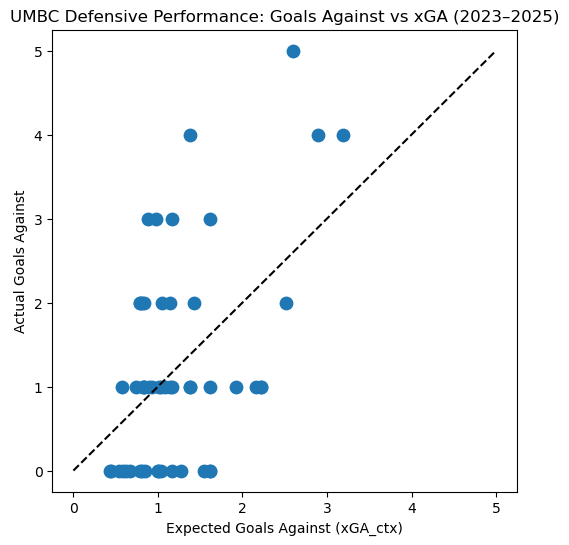

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(matches["xGA_ctx"], matches["goals_against"], s=80)
plt.plot([0,5],[0,5], linestyle="--", color="black")
plt.xlabel("Expected Goals Against (xGA_ctx)")
plt.ylabel("Actual Goals Against")
plt.title("UMBC Defensive Performance: Goals Against vs xGA (2023–2025)")
plt.show()


## Key Takeaways: Defensive xGA Model (2023–2025)

### 1. Defensive xGA Meaningfully Explains Goals Conceded
The relationship between **Actual Goals Against** and **Expected Goals Against (xGA_ctx)** is clearly positive. Matches with higher xGA generally correspond to more goals conceded, indicating that the model captures real defensive signal rather than random variation.

---

### 2. Shot Suppression Is the Primary Defensive Lever
- **Opponent shots on goal coefficient:** ≈ 0.16  
- **Multiplier:** ≈ 1.17 per additional opponent shot on goal

Each additional opponent shot on target increases UMBC’s expected goals conceded by roughly **17%**. This confirms that **limiting shots on goal is the most important defensive driver**.

---

### 3. Opponent Strength Strongly Increases Defensive Difficulty
- **Opponent strength multiplier:** ≈ 3.01  

Facing historically strong opponents (based on UMBC’s prior results) dramatically raises expected goals conceded. Defensive outcomes are therefore highly sensitive to **opponent quality**, even when shot volume is controlled.

---

### 4. Conference Context Alters Defensive Pressure
- **Conference main effect multiplier:** ≈ 0.81  
- **Conference × Opponent Strength multiplier:** ≈ 0.44  

On average, conference matches slightly suppress goals conceded. However, **strong conference opponents increase defensive difficulty far more than strong non-conference opponents**, reflecting greater tactical familiarity and execution in conference play.

---

### 5. Home Matches Slightly Increase Goals Against
- **Home multiplier:** ≈ 1.20  

UMBC concedes slightly more at home, likely reflecting a more aggressive attacking posture that increases defensive exposure rather than weaker defensive organization.

---

### 6. Conference vs Non-Conference Defensive Outcomes
- **Non-Conference Matches:**  
  - Higher opponent shots on goal  
  - Higher xGA and goals conceded  

- **Conference Matches:**  
  - Lower shot volume and xGA on average  
  - Defensive advantage disappears against strong conference opponents

---

### 7. Overall Interpretation
- Defensive performance is **systematic**, not random.
- Shot suppression and opponent quality dominate goals conceded.
- Conference play increases tactical difficulty rather than volatility.
- The model provides a strong foundation for defensive scouting, opponent-specific preparation, and future xGA refinements.

---

### Next Step
With both attacking xG and defensive xGA models established, the next step is to integrate them into a **match-level expected goal differential framework** to evaluate overall performance and tactical tradeoffs.
